In [2]:
#### start interactive session before nay heavy lifting
import os
# os.system("interact -q gpu -g 1 -m 32g -t 24:00:00")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import vector
vector.register_awkward()

In [ ]:
### working directory
dir = "work"
#### load 1000 jets
N = 100000
#### X_pythia == pythia four vectors of jets
#### y_pythia == ids
input_path = "/oscar/data/mleblan6/energyflow/datasets/QG_jets.npz"
# input_path = "/oscar/data/mleblan6/energyflow/datasets/QG_jets_herwig_0.npz"
with np.load(input_path) as input_data:
    print(len(input_data["X"]))
    input, labels = input_data["X"][:N], input_data["y"][:N]

input_path = "/oscar/data/mleblan6/lhay/autoencoder/output/QG_jets_pythia_PSAE_SWD_N100000_noSoftmaskOnPT.npz"
with np.load(input_path) as input_data:
    output, labels_decoded = input_data["X"][:N], input_data["y"][:N]

classes = ["gluon", "quark", "g_compressed", "q_compressed"]
colors = ["red", "blue", "orange", "green"]

100000


X_pythia contains (pt, $\eta$, $\phi$, PID) for the first 139 constituents of the jet.
X_herwig contains (pt, $\eta$, $\phi$, PID) for the first 136 constituents of the jet.
y_pythia and y_herwig contain an ID of whether the jet was quark (ID=1) or gluon(ID=0) initiated.

In [ ]:
def get_jet_vectors(p):
    pt  = p[:, :, 0]
    eta = p[:, :, 1]
    phi = p[:, :, 2]

    constituents = ak.zip(
        {
            "pt":   ak.Array(pt),
            "eta":  ak.Array(eta),
            "phi":  ak.Array(phi),
            "mass": ak.Array(np.zeros_like(pt)),  # massless assumption
        },
        with_name="Momentum4D",
    )
    jets = ak.sum(constituents, axis=1)   
    return jets, constituents

['t', 'z', 'x', 'y']
541.6606026481495
[542, 502, 525, 539, 545, 505, 539, 508, ..., 526, 518, 536, 535, 524, 527, 510]
{'charged hadrons': [211, -211, 321, -321, 2212, -2212], 'photons': [22], 'neutral hadrons': [130, 310, 2112], 'electrons': [11, -11], 'muons': [13, -13]}


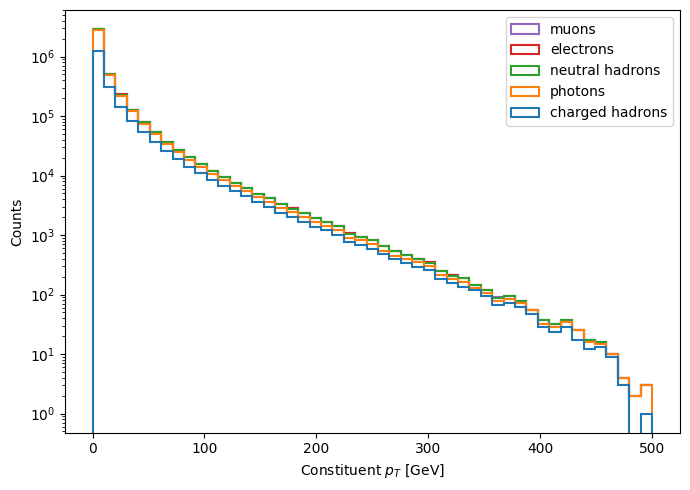

In [6]:
# plotting consituent pts
pid_map = {
    "charged hadrons": [211, -211, 321, -321, 2212, -2212],
    "photons": [22],
    "neutral hadrons": [130, 310, 2112],
    "electrons": [11, -11],
    "muons": [13, -13],
}

jets, particles = get_jet_vectors(input)
# flatten jets × constituents

# keep only filled constituents (pT > 0)
part_mask = particles.pt > 0
pid = input[:, :, 3]
#remove empty particles
# particles = particles[part_mask]
# pid = pid[part_mask]
jet_mask = jets.pt > 0
#remove empty jets
jets = jets[jet_mask]
print(jets.pt)
bins = np.linspace(0, 500, 50) 



plt.figure(figsize=(7, 5))
pts = []
for label, pdgs in pid_map.items():
    sel = np.isin(pid, pdgs)
    if np.any(sel):
        pts.append(particles.pt[sel])

plt.hist(
    pts,
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label=pid_map.keys(),
    stacked=True
)
        
plt.yscale("log")
plt.xlabel("Constituent $p_T$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

['t', 'z', 'x', 'y']
172.15102
100000
<class 'awkward.highlevel.Array'>
(100000,)
[172, 125, 169, 249, 169, 261, 231, 142, ..., 242, 193, 347, 123, 241, 162, 197]
[542, 502, 525, 539, 545, 505, 539, 508, ..., 526, 518, 536, 535, 524, 527, 510]


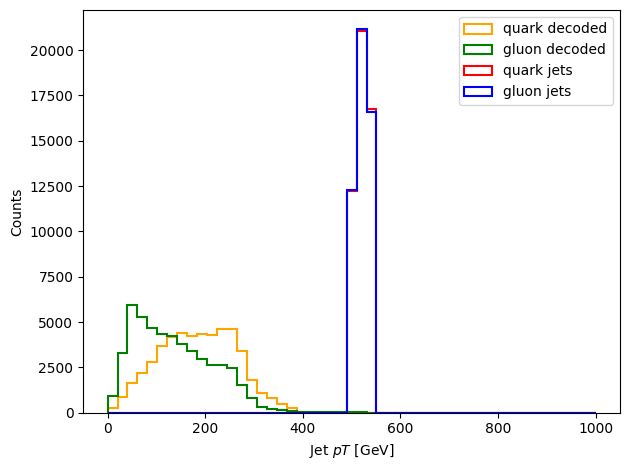

In [9]:
jets_decoded, particles_decoded = get_jet_vectors(output)
# flatten jets × constituents

# keep only filled constituents (pT > 0)
part_mask = particles_decoded.pt > 0
#remove empty particles
particles_decoded = particles_decoded[part_mask]
jet_mask = jets_decoded.pt > 0
#remove empty jets
jets_decoded = jets_decoded[jet_mask]
print(len(jets_decoded))
jet_pt = np.array(jets_decoded.pt)
print(type(jets_decoded.pt))
print(jet_pt.shape)
print(jets_decoded.pt)
bins = np.linspace(0, 500, 50) 

### plot 
bins = np.linspace(0, 1000, 50) 
labels_decoded = np.array(labels_decoded).astype(int)
mask = (labels_decoded == 0)
plt.hist(
            jet_pt[mask],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark decoded",
            color="orange"
        )
mask = (labels_decoded != 0)
plt.hist(
            jet_pt[mask],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon decoded",
            color="green"
        )

px = np.sum(particles.pt * np.cos(particles.phi), axis=1)
py = np.sum(particles.pt * np.sin(particles.phi), axis=1)

jet_pt = np.sqrt(px**2 + py**2)
mask = (labels == 0)
print(jets.pt)
plt.hist(
            jet_pt[mask],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark jets",
            color="red"
        )
mask = (labels != 0)
plt.hist(
            jet_pt[mask],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon jets",
            color="blue"
        )
        

plt.xlabel("Jet $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
# plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
jets_decoded, particles_decoded = get_jet_vectors(output)
# flatten jets × constituents

# keep only filled constituents (pT > 0)
part_mask = particles_decoded.pt > 0
#remove empty particles
particles_decoded = particles_decoded[part_mask]
#remove empty jets


### plot 
bins = np.linspace(0, 500, 50) 
labels_decoded = np.array(labels_decoded).astype(int)
mask = (labels_decoded == 0)
plt.hist(
            particles_decoded.pt,
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark decoded",
            color="orange"
        )
mask = (labels_decoded != 0)
plt.hist(
            particles_decoded.pt,
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon decoded",
            color="green"
        )

px = np.sum(particles.pt * np.cos(particles.phi), axis=1)
py = np.sum(particles.pt * np.sin(particles.phi), axis=1)

jet_pt = np.sqrt(px**2 + py**2)
mask = (labels == 0)
print(jets.pt)
plt.hist(
            particles.pt,
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark jets",
            color="red"
        )
mask = (labels != 0)
plt.hist(
            particles.pt,
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon jets",
            color="blue"
        )
        

plt.xlabel("Particle $p_T$ [GeV]")
plt.ylabel("Counts")
plt.legend()
# plt.yscale("log")
plt.tight_layout()
plt.show()

['t', 'z', 'x', 'y']
172.15102


In [ ]:
### plot 
bins = np.linspace(0, 500, 50) 
y_pythia = np.array(y_pythia).astype(int)
mask = (y_pythia == 0)
pt  = X_pythia[..., 0]
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (y_pythia != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
### plot 
bins = np.linspace(0, 500, 50) 
y_pythia = np.array(y_pythia).astype(int)
mask = (y_pythia == 0)
pt  = X_pythia[..., 0]
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (y_pythia != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()